In [1]:
# ==== Cell 0: setup seeds, split, class weights & sampler ====
import os, random, time, math
from pathlib import Path
from collections import defaultdict, Counter

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_DIR = Path("Data")
assert DATA_DIR.exists(), f"Not found: {DATA_DIR}"

# base dataset without transform (so we can stratify)
base_ds = datasets.ImageFolder(root=str(DATA_DIR))
num_classes = len(base_ds.classes)
print("Classes:", base_ds.classes)

# stratified train/val split (15% val)
VAL_RATIO = 0.19
cls_to_indices = defaultdict(list)
for i, (_, cls_idx) in enumerate(base_ds.samples):
    cls_to_indices[cls_idx].append(i)

train_idx, val_idx = [], []
for cls_idx, idxs in cls_to_indices.items():
    random.shuffle(idxs)
    n_val = max(1, int(len(idxs) * VAL_RATIO))
    val_idx += idxs[:n_val]
    train_idx += idxs[n_val:]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")

# class weights & sampler (computed on TRAIN only)
train_targets = [base_ds.samples[i][1] for i in train_idx]
counts = Counter(train_targets)
class_weights = torch.tensor([1.0 / max(1, counts[c]) for c in range(num_classes)], dtype=torch.float)

sample_weights = [class_weights[t].item() for t in train_targets]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

print("Train class counts:", {base_ds.classes[c]: counts[c] for c in range(num_classes)})


Device: cuda
Classes: ['Angry', 'Fear', 'Happy', 'Sad', 'Surprise']
Train: 47871 | Val: 11228
Train class counts: {'Angry': 8220, 'Fear': 7883, 'Happy': 14936, 'Sad': 10168, 'Surprise': 6664}


/home/nosrati/anaconda3/envs/ml_learning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==== Cell 1: transforms + dataloaders for both families ====
IMG224 = 224

tf_rgb_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(256, antialias=True),
    transforms.RandomResizedCrop(IMG224, scale=(0.8, 1.0), antialias=True),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

tf_rgb_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(256, antialias=True),
    transforms.CenterCrop(IMG224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

tf_gray48_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48,48), antialias=True),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5]),
])

tf_gray48_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48,48), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5]),
])

# build datasets per family
ds_rgb_train_full = datasets.ImageFolder(root=str(DATA_DIR), transform=tf_rgb_train)
ds_rgb_val_full   = datasets.ImageFolder(root=str(DATA_DIR), transform=tf_rgb_val)
ds_g48_train_full = datasets.ImageFolder(root=str(DATA_DIR), transform=tf_gray48_train)
ds_g48_val_full   = datasets.ImageFolder(root=str(DATA_DIR), transform=tf_gray48_val)

train_ds_map = {
    "rgb_224": Subset(ds_rgb_train_full, train_idx),
    "gray_48": Subset(ds_g48_train_full, train_idx),
}
val_ds_map = {
    "rgb_224": Subset(ds_rgb_val_full, val_idx),
    "gray_48": Subset(ds_g48_val_full, val_idx),
}

BATCH_SIZE = 370
pin = torch.cuda.is_available()
train_loader_map = {
    "rgb_224": DataLoader(train_ds_map["rgb_224"], batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=pin),
    "gray_48": DataLoader(train_ds_map["gray_48"], batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=pin),
}
val_loader_map = {
    "rgb_224": DataLoader(val_ds_map["rgb_224"], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin),
    "gray_48": DataLoader(val_ds_map["gray_48"], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin),
}


In [3]:
# ==== Cell 2: model zoo builders ====
from torchvision.models import (
    resnet18, ResNet18_Weights,
    resnet50, ResNet50_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    densenet121, DenseNet121_Weights,
    shufflenet_v2_x1_0, ShuffleNet_V2_X1_0_Weights,
    squeezenet1_1, SqueezeNet1_1_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights,
    vit_b_16, ViT_B_16_Weights,
)

def TinyCNN48(num_classes):
    return nn.Sequential(
        nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 48→24
        nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 24→12
        nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),# 12→6
        nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )

def build_resnet18():
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=1e-4)
    return m.to(device), "rgb_224", opt, crit

def build_mobilenetv3_large():
    m = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=1e-4)
    return m.to(device), "rgb_224", opt, crit

def build_efficientnet_b0():
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=1e-4)
    return m.to(device), "rgb_224", opt, crit

def build_densenet121():
    m = densenet121(weights=DenseNet121_Weights.DEFAULT)
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=1e-4)
    return m.to(device), "rgb_224", opt, crit

def build_shufflenet():
    m = shufflenet_v2_x1_0(weights=ShuffleNet_V2_X1_0_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=1e-4)
    return m.to(device), "rgb_224", opt, crit

def build_squeezenet():
    m = squeezenet1_1(weights=SqueezeNet1_1_Weights.DEFAULT)
    m.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
    m.num_classes = num_classes
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=1e-4)
    return m.to(device), "rgb_224", opt, crit

def build_resnet50():
    m = resnet50(weights=ResNet50_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=8e-5)
    return m.to(device), "rgb_224", opt, crit

def build_convnext_tiny():
    m = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    m.classifier[2] = nn.Linear(m.classifier[2].in_features, num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=8e-5)
    return m.to(device), "rgb_224", opt, crit

def build_vit_b16():
    m = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
    m.heads.head = nn.Linear(m.heads.head.in_features, num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.AdamW(m.parameters(), lr=2e-5, weight_decay=0.05)
    return m.to(device), "rgb_224", opt, crit

def build_tinycnn48():
    m = TinyCNN48(num_classes)
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    opt  = optim.Adam(m.parameters(), lr=3e-4)
    return m.to(device), "gray_48", opt, crit

MODEL_BUILDERS = {
    "resnet18":         build_resnet18,
    "mobilenetv3_l":    build_mobilenetv3_large,
    "efficientnet_b0":  build_efficientnet_b0,
    "densenet121":      build_densenet121,
    "shufflenet_v2":    build_shufflenet,
    "squeezenet1_1":    build_squeezenet,
    "resnet50":         build_resnet50,
    "convnext_tiny":    build_convnext_tiny,
    "vit_b16":          build_vit_b16,
    "tinycnn48":        build_tinycnn48,   # native 48×48 (no upscaling)
}


In [4]:
# ==== Cell 3: train/eval helpers + metrics ====
import torch.nn.functional as F

USE_AMP = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def count_params(model):  # in millions
    return sum(p.numel() for p in model.parameters()) / 1e6

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum = correct = total = 0
    pbar = tqdm(loader, desc="Train", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        if USE_AMP:
            with torch.amp.autocast('cuda'):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
    return loss_sum/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum = correct = total = 0
    pbar = tqdm(loader, desc="Valid", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()
        pbar.set_postfix(loss=f"{loss_sum/total:.4f}", acc=f"{correct/total:.4f}")
    return loss_sum/total, correct/total

@torch.no_grad()
def inference_throughput(model, loader, warmup=2, iters=10):
    model.eval()
    # simple timing on first N batches
    it = iter(loader)
    for _ in range(warmup):
        try:
            x,_ = next(it)
        except StopIteration:
            return None
        _ = model(x.to(device))
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()
    seen = 0
    for _ in range(iters):
        try:
            x,_ = next(it)
        except StopIteration:
            break
        _ = model(x.to(device))
        seen += x.size(0)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    dt = time.time() - start
    return seen / max(dt, 1e-6)


/tmp/ipykernel_231308/1143350030.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [5]:
import gc, torch, os

def cuda_mem(prefix=""):
    if not torch.cuda.is_available(): return
    torch.cuda.synchronize()
    a = torch.cuda.memory_allocated()/1e9
    r = torch.cuda.memory_reserved()/1e9
    print(f"{prefix} GPU mem  allocated={a:.3f} GB  reserved={r:.3f} GB")

def cleanup_cuda_model(model, optimizer=None, criterion=None):
    if model is not None:
        model.to("cpu")          # <-- get weights off GPU
    del model
    if optimizer is not None: del optimizer
    if criterion is not None: del criterion
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    gc.collect()
    torch.cuda.reset_peak_memory_stats()



===== resnet18 =====
[before build] GPU mem  allocated=0.000 GB  reserved=0.000 GB


Epoch 01 | train 0.9046/0.6267 | val 0.7909/0.7007


Epoch 02 | train 0.6308/0.7574 | val 0.6962/0.7291


Epoch 03 | train 0.4720/0.8253 | val 0.6272/0.7678


Epoch 04 | train 0.3777/0.8618 | val 0.5510/0.8009


...

Epoch 03 | train 1.0255/0.5728 | val 1.2607/0.5197


Epoch 04 | train 0.9521/0.6086 | val 1.2947/0.5097


Epoch 05 | train 0.8897/0.6378 | val 2.4037/0.2705


Throughput: 790.7 samples/s
Saved: ckpt_tinycnn48.pth
[after cleanup] GPU mem  allocated=0.020 GB  reserved=0.046 GB


,model,family,params_M,best_val_acc,best_val_loss,epochs,train_time_s,throughput_sps
3,densenet121,rgb_224,6.96,0.8345,0.4949,5,1364.5,361.6
2,efficientnet_b0,rgb_224,4.01,0.8313,0.4927,5,833.3,610.0
0,resnet18,rgb_224,11.18,0.8148,0.5323,5,599.0,502.1
1,mobilenetv3_l,rgb_224,4.21,0.8036,0.5551,5,689.1,684.3
4,shufflenet_v2,rgb_224,1.26,0.7423,0.6664,5,623.1,761.0
5,squeezenet1_1,rgb_224,0.73,0.6953,0.7805,5,633.2,768.3
6,tinycnn48,gray_48,0.39,0.5197,1.2607,5,305.9,790.7


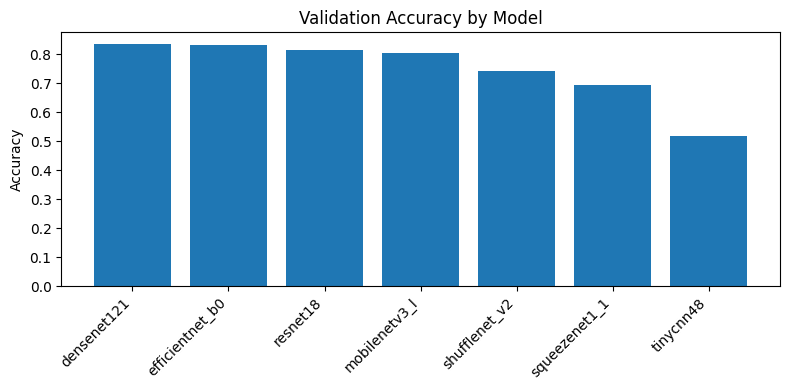

In [6]:
BATCH_FOR = {
    "resnet18":        300,
    "mobilenetv3_l":   64,   # smaller
    "efficientnet_b0": 64,
    "densenet121":     64,
    "shufflenet_v2":   64,
    "squeezenet1_1":   64,
    "resnet50":        64,
    "convnext_tiny":   64,
    "vit_b16":         64,
    "tinycnn48":       128,
}

MODELS_TO_RUN = [
    "resnet18",
    "mobilenetv3_l",
    "efficientnet_b0",
    "densenet121",
    "shufflenet_v2",
    "squeezenet1_1",
    "tinycnn48",
]

EPOCHS_PER_MODEL = 5
results, all_histories = [], []

for name in MODELS_TO_RUN:
    print(f"\n===== {name} =====")
    cuda_mem("[before build]")   # optional

    # ★ ensure previous model is gone
    try: cleanup_cuda_model(model, optimizer, criterion)
    except NameError: pass

    builder = MODEL_BUILDERS[name]
    model, family, optimizer, criterion = builder()

    # ★ per-model batch size
    batch = BATCH_FOR.get(name, 48)
    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_ds_map[family], batch_size=batch, sampler=sampler, num_workers=2, pin_memory=pin)
    val_loader   = DataLoader(val_ds_map[family],   batch_size=batch, shuffle=False,   num_workers=2, pin_memory=pin)

    params_m = count_params(model)
    best_val, best_loss = -1.0, float("inf")
    best_state = None
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    t0 = time.time()
    for epoch in range(1, EPOCHS_PER_MODEL+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
        print(f"Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f}")
        if va_acc > best_val:
            best_val, best_loss = va_acc, va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    train_time = time.time() - t0

    # restore best → move to CPU for saving
    if best_state is not None:
        model.load_state_dict(best_state)
    model.to("cpu")  # ★ move off GPU before saving

    tput = inference_throughput(model.to(device), val_loader) if torch.cuda.is_available() else None
    if torch.cuda.is_available(): model.to("cpu")  # put back to CPU

    ckpt_path = Path(f"ckpt_{name}.pth")
    torch.save({
        "model_state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
        "class_to_idx": base_ds.class_to_idx,
        "best_val_acc": best_val,
        "history": history,
        "params_m": params_m,
        "family": family,
    }, ckpt_path)
    print("Throughput:", "N/A" if tput is None else f"{tput:.1f} samples/s")
    print("Saved:", ckpt_path)

    results.append({
        "model": name,
        "family": family,
        "params_M": round(params_m, 2),
        "best_val_acc": round(best_val, 4),
        "best_val_loss": round(best_loss, 4),
        "epochs": EPOCHS_PER_MODEL,
        "train_time_s": round(train_time, 1),
        "throughput_sps": None if tput is None else round(float(tput), 1),
    })

    # ★ hard cleanup before next model
    cleanup_cuda_model(model, optimizer, criterion)
    del train_loader, val_loader, history, best_state
    cuda_mem("[after cleanup]")

df_res = pd.DataFrame(results).sort_values("best_val_acc", ascending=False)
display(df_res)

plt.figure(figsize=(8,4))
plt.bar(df_res["model"], df_res["best_val_acc"])
plt.title("Validation Accuracy by Model"); plt.ylabel("Accuracy"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
import numpy as np
import matplotlib.pyplot as plt
import torch
@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        y_pred.append(logits.argmax(1).cpu().numpy())
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)
def compute_metrics(y_true, y_pred, labels, target_names):
    # overall
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    # per-class
    p_cls, r_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=labels, zero_division=0
    )

    # confmat + report
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    report_txt = classification_report(
        y_true, y_pred, labels=labels, target_names=target_names, digits=4, zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "precision_weighted": p_weight,
        "recall_weighted": r_weight,
        "f1_weighted": f1_weight,
        "per_class": {
            "precision": dict(zip(target_names, p_cls)),
            "recall":    dict(zip(target_names, r_cls)),
            "f1":        dict(zip(target_names, f1_cls)),
            "support":   dict(zip(target_names, sup_cls)),
        },
        "confusion_matrix": cm,
        "classification_report": report_txt,
    }
    return metrics

def plot_confusion_matrix(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right"); ax.set_yticklabels(classes)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt = f"{cm[i,j]:.2f}" if normalize else str(cm[i,j])
            ax.text(j, i, txt, ha="center", va="center", fontsize=8)
    fig.colorbar(im); plt.tight_layout(); plt.show()
# choose class mapping (works with your earlier code)
try:
    idx_to_class = {v: k for k, v in train_full.class_to_idx.items()}
except NameError:
    idx_to_class = {v: k for k, v in base_ds.class_to_idx.items()}  # if using model zoo setup

labels = list(range(len(idx_to_class)))
target_names = [idx_to_class[i] for i in labels]

# pick the right val_loader object in your notebook
# e.g., if you have a single model: use `val_loader`
# if you're in the model-zoo: use `val_loader = val_loader_map[family]`

print("Overall:")
print(f"  accuracy         : {m['accuracy']:.4f}")
print(f"  precision_macro  : {m['precision_macro']:.4f}")
print(f"  recall_macro     : {m['recall_macro']:.4f}")
print(f"  f1_macro         : {m['f1_macro']:.4f}")
print(f"  f1_weighted      : {m['f1_weighted']:.4f}")

print("\nPer-class (f1):")
for cls, f1 in m["per_class"]["f1"].items():
    print(f"  {cls:>10}: {f1:.4f}")

print("\nClassification report:")
print(m["classification_report"])

plot_confusion_matrix(m["confusion_matrix"], target_names, normalize=False,
                      title="Confusion Matrix (counts)")
plot_confusion_matrix(m["confusion_matrix"], target_names, normalize=True,
                      title="Confusion Matrix (row-normalized)")

y_true, y_pred = collect_preds(model, val_loader, device)
metrics = compute_metrics(y_true, y_pred, labels=list(range(num_classes)),
                          target_names=[base_ds.classes[i] for i in range(num_classes)])

results.append({
    "model": name,
    "family": family,
    "params_M": round(params_m, 2),
    "best_val_acc": round(metrics["accuracy"], 4),          # use sklearn accuracy
    "f1_macro": round(metrics["f1_macro"], 4),
    "f1_weighted": round(metrics["f1_weighted"], 4),
    "epochs": EPOCHS_PER_MODEL,
    "train_time_s": round(train_time, 1),
    "throughput_sps": None if tput is None else round(float(tput), 1),
})


NameError: name 'y_true' is not defined